# SSE Ionic Conductivity Surrogate Model — All Phases
### Crystal Paradigm | Target: R² > 0.90

**Strategy:** Predict `log(min_barrier)` → convert to conductivity via Arrhenius  
**Why:** `log10_conductivity` was derived FROM `min_barrier` — predicting it directly is circular

| Phase | What | Expected R² |
|-------|------|-------------|
| 1 | Tabular features only | ~0.55 |
| 2 | + CIF structural features (pymatgen) | ~0.68 |
| 3 | + Composition features (formula parsing) | ~0.75 |
| 4 | + M3GNet 64-dim embeddings | ~0.85–0.92 |
| Final | Stacked ensemble | **>0.90** |

**Files needed in ``:**
- `lithium_dataset_full_cleaned.csv` ✅
- `lithium_cifs_9956.zip` ✅


In [4]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Install all dependencies
# Runtime → Run all  OR  run cells one by one
# ════════════════════════════════════════════════════════════
import subprocess, sys

# Core ML
!pip install scikit-learn pandas numpy matplotlib seaborn joblib xgboost lightgbm -q

# Materials science (fixing specific versions for Colab stability)
!pip install pymatgen==2023.12.18 matgl==0.9.0 -q

# M3GNet embeddings (GPU-accelerated)
!pip install dgl -f https://data.dgl.ai/wheels/cu121/repo.html -q

# SHAP for explainability
!pip install shap -q

print('✅ All packages downloaded.')

# ── Checkpoint: Verify matgl installed correctly ──
try:
    import matgl
    from matgl.ext.pymatgen import Structure2Graph
    print('✅ CHECKPOINT PASSED: matgl installed and imported successfully! Phase 4 is ready.')
except ImportError as e:
    print(f'❌ CHECKPOINT FAILED: matgl failed to import. Error: {e}')
    print('⚠️  Cell 12 (M3GNet) will safely skip Phase 4 if you continue, but the rest will work.')
except Exception as e:
    print(f'❌ CHECKPOINT FAILED: Unexpected error with matgl: {e}')

✅ All packages downloaded.
✅ CHECKPOINT PASSED: matgl installed and imported successfully! Phase 4 is ready.


In [5]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Imports
# ════════════════════════════════════════════════════════════
import os, zipfile, warnings, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance

print('✅ Imports done')

✅ Imports done


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 3 — Load dataset
# ════════════════════════════════════════════════════════════
import os
import pandas as pd
import subprocess

# If running on Google Colab, optionally mount Google Drive
try:
    import google.colab
    in_colab = True
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
except ImportError:
    in_colab = False

# Download from the user's specific Google Drive folder link if in Colab
if in_colab:
    print('Checking for files from the shared Google Drive folder...')
    if not os.path.exists('/content/context'):
        print('Downloading folder from Google Drive link...')
        subprocess.run(['pip', 'install', 'gdown', '-q'])
        subprocess.run(['gdown', '--folder', 'https://drive.google.com/drive/folders/19Rl4XjpWyr_3pa8Z2uYTzx00pOy6j9r7', '-O', '/content/context'])
        print('Download complete.')

CSV_PATH = 'lithium_dataset_full_cleaned.csv'

# Extensive list of search locations
fallbacks = [
    CSV_PATH,
    r'E:\context\lithium_dataset_full_cleaned.csv',
    '/content/lithium_dataset_full_cleaned.csv',
    '/content/context/lithium_dataset_full_cleaned.csv',
    '/content/drive/MyDrive/context/lithium_dataset_full_cleaned.csv',
    '/content/drive/MyDrive/lithium_dataset_full_cleaned.csv',
    '/content/context/lithium_dataset_full_cleaned/lithium_dataset_full_cleaned.csv' # in case of nested
]

file_found = False
for fallback in fallbacks:
    if os.path.exists(fallback):
        CSV_PATH = fallback
        file_found = True
        break

# Deep search if in Colab and not yet found
if not file_found and os.path.exists('/content'):
    print('Searching for CSV in Colab environment...')
    for root, dirs, files in os.walk('/content'):
        if 'lithium_dataset_full_cleaned.csv' in files:
            CSV_PATH = os.path.join(root, 'lithium_dataset_full_cleaned.csv')
            file_found = True
            break

try:
    df_raw = pd.read_csv(CSV_PATH)
    print(f'✅ Loaded: {CSV_PATH}')
    print(f'   Shape : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
except Exception as e:
    print(f'❌ Error loading dataset: {e}')
    print('Please check that lithium_dataset_full_cleaned.csv is uploaded.')

Checking for files from the shared Google Drive folder...
✅ Loaded: /content/context/lithium_dataset_full_cleaned.csv
   Shape : 9956 rows × 35 columns


---
## PHASE 1 — Target Reframing, Leakage Removal, Feature Engineering


In [7]:
# ════════════════════════════════════════════════════════════

# CELL 4 — Phase 1: Clean + target prep

# ════════════════════════════════════════════════════════════



import numpy as np

from sklearn.preprocessing import LabelEncoder



df = df_raw.copy()

print(f'Raw dataset: {df.shape[0]} rows × {df.shape[1]} columns')



# ── Step 1: Compute derived features BEFORE dropping max_barrier ──

df['bulk_modulus_GPa']  = df['K_GPa']                             # fix 100% NaN

df['shear_modulus_GPa'] = df['G_GPa']                             # fix 100% NaN

df['pugh_ratio']        = df['K_GPa'] / (df['G_GPa'] + 1e-8)     # ductility K/G

df['debye_proxy']       = np.sqrt(df['K_GPa'].abs() / (df['density'] + 1e-8))  # phonon stiffness



# ── Step 2: Log-transform target ──

# σ = A*exp(-Ea/kT) → log(σ) ∝ -min_barrier

# Predicting log(min_barrier) directly — no circular derivation

df['log_min_barrier'] = np.log(df['min_barrier'] + 1e-3)



# ── Step 3: Remove ALL leakage columns ──

LEAKAGE = [

    'log10_conductivity_300K',   # derived FROM min_barrier — circular

    'diffusion_coefficient_300K',# Nernst-Einstein links to conductivity

    'li_transference_number',    # computed from conductivity

    'transference_category',     # binned transference number

    'mean_barrier',              # same AIMD run as min_barrier

    'max_barrier',               # same AIMD provenance as target

    'num_hops',                  # AIMD simulation artifact

    'time_seconds',              # AIMD wall-clock — not a material property

    'bulk_modulus_GPa',          # 100% NaN original

    'shear_modulus_GPa',         # 100% NaN original

    'toughness_B_G_ratio',       # 100% NaN original

    'material_id',

    'formula_pretty',

]

df.drop(columns=[c for c in LEAKAGE if c in df.columns], inplace=True)



# ── Step 4: Clip unphysical barriers ──

before = len(df)

df = df[(df['min_barrier'] >= 0.01) & (df['min_barrier'] <= 5.0)].copy()

print(f'Outliers removed: {before - len(df)} (barrier > 5 eV or < 0.01 eV)')



# Recompute after clip

df['log_min_barrier'] = np.log(df['min_barrier'] + 1e-3)



# ── Step 5: Encode categoricals ──

CAT_COLS = ['thermal_stability','electronic_conductivity_category','ductile_brittle']

le_dict = {}

for col in CAT_COLS:

    if col in df.columns:

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col].astype(str))

        le_dict[col] = le

if 'is_stable' in df.columns:

    df['is_stable'] = df['is_stable'].astype(int)



print(f'✅ Phase 1 complete | Rows: {len(df)} | Columns: {df.shape[1]}')

print(f'   Target: log_min_barrier range [{df["log_min_barrier"].min():.3f}, {df["log_min_barrier"].max():.3f}]')

Raw dataset: 9956 rows × 35 columns
Outliers removed: 0 (barrier > 5 eV or < 0.01 eV)
✅ Phase 1 complete | Rows: 9956 | Columns: 28
   Target: log_min_barrier range [-4.143, 0.485]


In [8]:
# ════════════════════════════════════════════════════════════
# CELL 5 — Phase 1: Feature engineering (interaction terms)
# ════════════════════════════════════════════════════════════

# Structural geometry
df['volume_per_atom']    = df['volume']    / (df['n_atoms']  + 1e-8)
df['energy_per_volume']  = df['energy_eV'] / (df['volume']   + 1e-8)
df['K_over_density']     = df['K_GPa']     / (df['density']  + 1e-8)
df['G_over_density']     = df['G_GPa']     / (df['density']  + 1e-8)
df['K_times_G']          = df['K_GPa']     * df['G_GPa']

# Log transforms (compress skewed distributions)
df['log_volume']         = np.log(df['volume']   + 1e-8)
df['log_density']        = np.log(df['density']  + 1e-8)
df['log_n_atoms']        = np.log(df['n_atoms']  + 1e-8)
df['sqrt_K']             = np.sqrt(df['K_GPa'].abs())
df['sqrt_G']             = np.sqrt(df['G_GPa'].abs())

# Thermodynamic cross terms
df['formation_x_hull']   = df['formation_energy_per_atom'] * (df['energy_above_hull'] + 1e-8)
df['energy_stability']   = df['energy_per_atom_eV'] * (1 - df['energy_above_hull'].clip(0, 1))

print(f'✅ Feature engineering done | Total features: {df.shape[1] - 2}')
print(f'   (minus min_barrier and log_min_barrier = X features)')

✅ Feature engineering done | Total features: 38
   (minus min_barrier and log_min_barrier = X features)


In [9]:
# ════════════════════════════════════════════════════════════
# CELL 6 — Define X, y and baseline model (Phase 1)
# ════════════════════════════════════════════════════════════

TARGET = 'log_min_barrier'
X_tab = df.drop(columns=['min_barrier', TARGET])
y     = df[TARGET]

X_tr, X_te, y_tr, y_te = train_test_split(X_tab, y, test_size=0.2, random_state=42)

baseline = HistGradientBoostingRegressor(
    max_iter=600, learning_rate=0.03, max_depth=8,
    min_samples_leaf=10, l2_regularization=0.05,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=40, random_state=42
)
baseline.fit(X_tr, y_tr)

r2_p1  = r2_score(y_te, baseline.predict(X_te))
mae_p1 = mean_absolute_error(y_te, baseline.predict(X_te))

print(f'Phase 1 Baseline → R² = {r2_p1:.4f} | MAE = {mae_p1:.4f}')
print(f'Features used: {X_tab.shape[1]}')
print()
print('Target: add CIF features in Phase 2 to push R² toward 0.90+')

Phase 1 Baseline → R² = 0.5339 | MAE = 0.3925
Features used: 38

Target: add CIF features in Phase 2 to push R² toward 0.90+


---
## PHASE 2 — CIF Structural Feature Extraction (pymatgen)


In [10]:
# ════════════════════════════════════════════════════════════
# CELL 7 — Extract / Set CIF directory
# ════════════════════════════════════════════════════════════
import os
import zipfile
import subprocess

CIF_DIR = 'lithium_cifs_9956'

# Try to find an existing unzipped directory first
dir_fallbacks = [
    CIF_DIR,
    r'E:\context\lithium_cifs_9956',
    '/content/lithium_cifs_9956',
    '/content/context/lithium_cifs_9956',
    '/content/drive/MyDrive/context/lithium_cifs_9956',
    '/content/drive/MyDrive/lithium_cifs_9956'
]

dir_found = False
for fallback in dir_fallbacks:
    if os.path.isdir(fallback) and len([f for f in os.listdir(fallback) if f.endswith('.cif')]) > 0:
        CIF_DIR = fallback
        dir_found = True
        break

# Handle double-nested edge case from some zip extractions
if os.path.isdir(os.path.join(CIF_DIR, 'lithium_cifs_9956')):
    CIF_DIR = os.path.join(CIF_DIR, 'lithium_cifs_9956')

if not dir_found:
    print('CIF directory missing or empty. Searching for zip file to extract...')
    
    # Try downloading from GDrive folder directly if it wasn't done yet in Cell 3
    if os.path.exists('/content') and not os.path.exists('/content/context/lithium_cifs_9956.zip'):
        print('Attempting to download zip from the provided Google Drive link...')
        subprocess.run(['pip', 'install', 'gdown', '-q'])
        subprocess.run(['gdown', '--folder', 'https://drive.google.com/drive/folders/19Rl4XjpWyr_3pa8Z2uYTzx00pOy6j9r7', '-O', '/content/context'])
        
    ZIP_PATH = 'lithium_cifs_9956.zip'
    zip_fallbacks = [
        ZIP_PATH,
        r'E:\context\lithium_cifs_9956.zip',
        '/content/lithium_cifs_9956.zip',
        '/content/context/lithium_cifs_9956.zip',
        '/content/context/lithium_cifs_9956/lithium_cifs_9956.zip',
        '/content/drive/MyDrive/context/lithium_cifs_9956.zip',
        '/content/drive/MyDrive/lithium_cifs_9956.zip',
        '/content/drive/MyDrive/Colab Notebooks/lithium_cifs_9956.zip',
        '/content/drive/MyDrive/Colab Notebooks/context/lithium_cifs_9956.zip'
    ]
    
    zip_found = False
    for fb in zip_fallbacks:
        if os.path.exists(fb):
            ZIP_PATH = fb
            zip_found = True
            break
            
    if not zip_found and os.path.exists('/content/drive/MyDrive'):
        print('Scanning entire Google Drive for the zip file (this may take a minute)...')
        for root, dirs, files in os.walk('/content/drive/MyDrive'):
            if 'lithium_cifs_9956.zip' in files:
                ZIP_PATH = os.path.join(root, 'lithium_cifs_9956.zip')
                zip_found = True
                break
                
    if zip_found:
        # If in Colab, extract to local SSD (/content) to avoid Google Drive I/O bottlenecks
        if os.path.exists('/content'):
            extract_target = '/content'
            print(f'Found zip at {ZIP_PATH}. \nExtracting to local Colab SSD ({extract_target}) for maximum speed...')
        else:
            extract_target = os.path.dirname(ZIP_PATH) or '.'
            print(f'Found zip at {ZIP_PATH}. Extracting...')
            
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(extract_target)
        
        CIF_DIR = os.path.join(extract_target, 'lithium_cifs_9956')
        if os.path.isdir(os.path.join(CIF_DIR, 'lithium_cifs_9956')):
            CIF_DIR = os.path.join(CIF_DIR, 'lithium_cifs_9956')
        print(f'✅ Extracted to {CIF_DIR}')
    else:
        print('❌ Could not find lithium_cifs_9956.zip! If it is in a shared folder, please add a Shortcut to "My Drive".')

if os.path.exists(CIF_DIR):
    cif_files = [f for f in os.listdir(CIF_DIR) if f.endswith('.cif')]
    print(f'✅ CIF directory ready: {CIF_DIR}')
    print(f'   CIF files found: {len(cif_files)}')
    print(f'   Sample: {cif_files[:3]}')

✅ CIF directory ready: lithium_cifs_9956
   CIF files found: 9956
   Sample: ['mp-776398.cif', 'mp-26365.cif', 'mp-766810.cif']


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 8 — CIF feature extractor function
# Extracts 22 structural descriptors per material
# ════════════════════════════════════════════════════════════

from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

CRYSTAL_SYSTEM_MAP = {
    'triclinic':1,'monoclinic':2,'orthorhombic':3,
    'tetragonal':4,'trigonal':5,'hexagonal':6,'cubic':7
}

def extract_cif_features(cif_path):
    """
    Extract 22 structural descriptors from a CIF file.
    Returns dict of float features.
    """
    struct = Structure.from_file(cif_path)
    lat    = struct.lattice
    feats  = {}

    # ── Lattice geometry ──
    feats['cif_lat_a']       = lat.a
    feats['cif_lat_b']       = lat.b
    feats['cif_lat_c']       = lat.c
    feats['cif_lat_alpha']   = lat.alpha
    feats['cif_lat_beta']    = lat.beta
    feats['cif_lat_gamma']   = lat.gamma
    feats['cif_lat_volume']  = lat.volume
    feats['cif_density']     = struct.density

    # ── Packing fraction ──
    sphere_vol = sum(
        (4/3)*np.pi*(float(site.specie.atomic_radius or 1.5))**3
        for site in struct
    )
    feats['cif_packing_fraction'] = sphere_vol / lat.volume 

    # ── Composition statistics ──
    en_vals = [getattr(s.specie, 'X', 0) or 0 for s in struct]
    ar_vals = [float(s.specie.atomic_radius or 1.5) for s in struct]
    ve_vals = [getattr(s.specie, 'valence', 0) or 0 for s in struct]
    am_vals = [float(s.specie.atomic_mass) for s in struct]

    feats['cif_mean_en']     = float(np.mean(en_vals))
    feats['cif_std_en']      = float(np.std(en_vals))
    feats['cif_mean_radius'] = float(np.mean(ar_vals))
    feats['cif_std_radius']  = float(np.std(ar_vals))
    feats['cif_mean_mass']   = float(np.mean(am_vals))
    feats['cif_std_mass']    = float(np.std(am_vals))

    # ── Coordination environment ──
    cn_vals, bl_vals = [], []
    for i, site in enumerate(struct):
        neighbors = struct.get_neighbors(site, r=3.5)
        cn_vals.append(len(neighbors))
        bl_vals.extend([n.nn_distance for n in neighbors])

    feats['cif_mean_cn']          = float(np.mean(cn_vals))  if cn_vals else 0.0
    feats['cif_std_cn']           = float(np.std(cn_vals))   if cn_vals else 0.0
    feats['cif_mean_bond_length'] = float(np.mean(bl_vals))  if bl_vals else 0.0
    feats['cif_std_bond_length']  = float(np.std(bl_vals))   if bl_vals else 0.0

    # ── Symmetry ──
    try:
        sga = SpacegroupAnalyzer(struct)
        feats['cif_spacegroup']      = sga.get_space_group_number()
        feats['cif_crystal_system']  = CRYSTAL_SYSTEM_MAP.get(sga.get_crystal_system(), 0)
    except:
        feats['cif_spacegroup']     = 0
        feats['cif_crystal_system'] = 0

    # ── Li-specific ──
    li_count = sum(1 for s in struct if s.specie.symbol == 'Li')
    feats['cif_li_count']    = li_count
    feats['cif_li_fraction'] = li_count / len(struct)

    return feats

# Test on one file
test_cif = os.path.join(CIF_DIR, cif_files[0])
test_feat = extract_cif_features(test_cif)
print(f'✅ CIF extractor ready — {len(test_feat)} features per material')
print(f'   Sample from {cif_files[0]}:')
for k, v in list(test_feat.items())[:5]:
    print(f'   {k}: {v:.4f}')

✅ CIF extractor ready — 23 features per material
   Sample from mp-776398.cif:
   cif_lat_a: 8.3742
   cif_lat_b: 8.5043
   cif_lat_c: 8.5325
   cif_lat_alpha: 64.7182
   cif_lat_beta: 65.1940


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 9 — Run CIF extraction on all 9,956 materials
# Expected time: ~25-40 minutes on Colab CPU
# Uses cached CSV if already run before
# ════════════════════════════════════════════════════════════

# Try to look for pre-existing cache to avoid full re-run
cached_fallbacks = [
    'cif_features_all.csv',
    r'E:\context\cif_features_all.csv',
    '/content/cif_features_all.csv',
    '/content/context/cif_features_all.csv',
    '/content/drive/MyDrive/context/cif_features_all.csv',
    '/content/drive/MyDrive/cif_features_all.csv'
]

CIF_FEATURES_CSV = 'cif_features_all.csv'
for fb in cached_fallbacks:
    if os.path.exists(fb):
        CIF_FEATURES_CSV = fb
        break
        
if os.path.exists(CIF_FEATURES_CSV):
    print(f'✅ Loading cached CIF features from {CIF_FEATURES_CSV}...')
    cif_df = pd.read_csv(CIF_FEATURES_CSV, index_col='material_id')
    print(f'   Loaded {len(cif_df)} materials × {cif_df.shape[1]} CIF features')
else:
    print('Extracting CIF features for all materials...')
    print('Expected time: ~25-40 mins on CPU | ~8-12 mins on GPU')

    # Get material IDs from original dataset
    df_ids = pd.read_csv(CSV_PATH, usecols=['material_id'])

    records, errors = [], []
    t0 = time.time()

    for i, mid in enumerate(df_ids['material_id']):
        cif_path = os.path.join(CIF_DIR, f'{mid}.cif')
        if not os.path.exists(cif_path):
            errors.append(mid)
            continue
        try:
            feats = extract_cif_features(cif_path)
            feats['material_id'] = mid
            records.append(feats)
        except Exception as e:
            errors.append(mid)

        if (i+1) % 500 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i+1) * (len(df_ids) - i - 1)
            print(f'  [{i+1}/{len(df_ids)}] Errors: {len(errors)} | ETA: {eta/60:.1f} min')

    cif_df = pd.DataFrame(records).set_index('material_id')
    # Save the file. If inside Google drive environment we can try to save there, otherwise local.
    target_csv = '/content/drive/MyDrive/cif_features_all.csv' if os.path.exists('/content/drive/MyDrive') else 'cif_features_all.csv'
    cif_df.to_csv(target_csv)
    print(f'\n✅ CIF extraction complete')
    print(f'   Extracted: {len(records)} | Failed: {len(errors)}')
    print(f'   Saved to {target_csv}')

✅ Loading cached CIF features from /content/drive/MyDrive/cif_features_all.csv...
   Loaded 8557 materials × 23 CIF features


In [13]:
# ════════════════════════════════════════════════════════════

# CELL 10 — Merge CIF features with tabular + Phase 2 model

# ════════════════════════════════════════════════════════════



# Re-load original with material_id for merge

df_with_id = pd.read_csv(CSV_PATH)



# Apply all Phase 1 transforms

df_with_id['pugh_ratio']       = df_with_id['K_GPa'] / (df_with_id['G_GPa'] + 1e-8)

df_with_id['debye_proxy']      = np.sqrt(df_with_id['K_GPa'].abs() / (df_with_id['density'] + 1e-8))

df_with_id['volume_per_atom']  = df_with_id['volume'] / (df_with_id['n_atoms'] + 1e-8)

df_with_id['energy_per_volume']= df_with_id['energy_eV'] / (df_with_id['volume'] + 1e-8)

df_with_id['K_over_density']   = df_with_id['K_GPa'] / (df_with_id['density'] + 1e-8)

df_with_id['G_over_density']   = df_with_id['G_GPa'] / (df_with_id['density'] + 1e-8)

df_with_id['K_times_G']        = df_with_id['K_GPa'] * df_with_id['G_GPa']

df_with_id['log_volume']       = np.log(df_with_id['volume'] + 1e-8)

df_with_id['log_density']      = np.log(df_with_id['density'] + 1e-8)

df_with_id['sqrt_K']           = np.sqrt(df_with_id['K_GPa'].abs())

df_with_id['sqrt_G']           = np.sqrt(df_with_id['G_GPa'].abs())

df_with_id['formation_x_hull'] = df_with_id['formation_energy_per_atom'] * (df_with_id['energy_above_hull'] + 1e-8)

df_with_id['log_min_barrier']  = np.log(df_with_id['min_barrier'] + 1e-3)



LEAKAGE = ['log10_conductivity_300K','diffusion_coefficient_300K','li_transference_number',

    'transference_category','mean_barrier','max_barrier','num_hops','time_seconds',

    'bulk_modulus_GPa','shear_modulus_GPa','toughness_B_G_ratio','formula_pretty']

df_with_id.drop(columns=[c for c in LEAKAGE if c in df_with_id.columns], inplace=True)

df_with_id = df_with_id[(df_with_id['min_barrier']>=0.01)&(df_with_id['min_barrier']<=5.0)].copy()

df_with_id['log_min_barrier'] = np.log(df_with_id['min_barrier'] + 1e-3)



for col in ['thermal_stability','electronic_conductivity_category','ductile_brittle']:

    if col in df_with_id.columns:

        df_with_id[col] = le_dict[col].transform(df_with_id[col].astype(str))

if 'is_stable' in df_with_id.columns:

    df_with_id['is_stable'] = df_with_id['is_stable'].astype(int)



# Merge with CIF features

df_merged = df_with_id.set_index('material_id').join(cif_df, how='left')

df_merged.fillna(df_merged.median(numeric_only=True), inplace=True)



TARGET = 'log_min_barrier'

X_cif = df_merged.drop(columns=['min_barrier', TARGET])

y_cif = df_merged[TARGET]



X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_cif, y_cif, test_size=0.2, random_state=42)



m2 = HistGradientBoostingRegressor(

    max_iter=800, learning_rate=0.02, max_depth=10,

    min_samples_leaf=8, l2_regularization=0.02,

    early_stopping=True, validation_fraction=0.1,

    n_iter_no_change=50, random_state=42

)

m2.fit(X_tr2, y_tr2)



r2_p2  = r2_score(y_te2, m2.predict(X_te2))

mae_p2 = mean_absolute_error(y_te2, m2.predict(X_te2))



print(f'Phase 1 (tabular only)     → R² = {r2_p1:.4f}')

print(f'Phase 2 (+CIF structural)  → R² = {r2_p2:.4f}  (+{r2_p2-r2_p1:.4f})')

print(f'Total features: {X_cif.shape[1]}')

Phase 1 (tabular only)     → R² = 0.5339
Phase 2 (+CIF structural)  → R² = 0.6463  (+0.1125)
Total features: 59


---
## PHASE 3 — Composition Features from Formula


In [14]:
# ════════════════════════════════════════════════════════════
# CELL 11 — Phase 3: Composition features via pymatgen
# Fast — ~2 minutes for all 9,919 materials
# ════════════════════════════════════════════════════════════

from pymatgen.core.composition import Composition

COMP_CSV = 'composition_features.csv'

if os.path.exists(COMP_CSV):
    comp_df = pd.read_csv(COMP_CSV, index_col='material_id')
    print(f'✅ Loaded cached composition features: {comp_df.shape}')
else:
    df_formula = pd.read_csv(CSV_PATH, usecols=['material_id','formula_pretty'])
    records = []
    for _, row in df_formula.iterrows():
        mid, formula = row['material_id'], row['formula_pretty']
        try:
            comp  = Composition(formula)
            items = list(comp.items())
            total = sum(v for _, v in items)
            ens   = [el.X for el, _ in items]
            radii = [float(el.atomic_radius or 1.5) for el, _ in items]
            masses= [float(el.atomic_mass) for el, _ in items]
            vals  = [getattr(el, 'valence', 0) or 0 for el, _ in items]
            li_amt= float(comp.get('Li', 0))
            records.append({
                'material_id':           mid,
                'comp_li_frac':          li_amt / total,
                'comp_n_elements':       len(items),
                'comp_mean_en':          np.mean(ens),
                'comp_std_en':           np.std(ens),
                'comp_max_en':           max(ens),
                'comp_min_en':           min(ens),
                'comp_en_spread':        max(ens) - min(ens),
                'comp_mean_radius':      np.mean(radii),
                'comp_std_radius':       np.std(radii),
                'comp_mean_mass':        np.mean(masses),
                'comp_std_mass':         np.std(masses),
                'comp_mean_valence':     np.mean(vals),
                'comp_stoich_entropy':   -sum((v/total)*np.log(v/total+1e-9) for _,v in items),
            })
        except:
            records.append({'material_id': mid, **{k: 0 for k in [
                'comp_li_frac','comp_n_elements','comp_mean_en','comp_std_en',
                'comp_max_en','comp_min_en','comp_en_spread','comp_mean_radius',
                'comp_std_radius','comp_mean_mass','comp_std_mass','comp_mean_valence',
                'comp_stoich_entropy']}})

    comp_df = pd.DataFrame(records).set_index('material_id')
    comp_df.to_csv(COMP_CSV)
    print(f'✅ Composition features extracted: {comp_df.shape}')

# Merge into dataset
df_merged2 = df_merged.join(comp_df, how='left')
df_merged2.fillna(df_merged2.median(numeric_only=True), inplace=True)

X_comp = df_merged2.drop(columns=['min_barrier', TARGET])
y_comp = df_merged2[TARGET]

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_comp, y_comp, test_size=0.2, random_state=42)

m3 = HistGradientBoostingRegressor(
    max_iter=800, learning_rate=0.02, max_depth=10,
    min_samples_leaf=8, l2_regularization=0.02,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=50, random_state=42
)
m3.fit(X_tr3, y_tr3)
r2_p3  = r2_score(y_te3, m3.predict(X_te3))
mae_p3 = mean_absolute_error(y_te3, m3.predict(X_te3))

print(f'Phase 1 (tabular only)         → R² = {r2_p1:.4f}')
print(f'Phase 2 (+CIF structural)      → R² = {r2_p2:.4f}')
print(f'Phase 3 (+composition formula) → R² = {r2_p3:.4f}  (+{r2_p3-r2_p2:.4f})')
print(f'Total features: {X_comp.shape[1]}')

✅ Loaded cached composition features: (9956, 13)
Phase 1 (tabular only)         → R² = 0.5339
Phase 2 (+CIF structural)      → R² = 0.6463
Phase 3 (+composition formula) → R² = 0.6568  (+0.0105)
Total features: 72


---
## PHASE 4 — M3GNet 64-dim Structural Embeddings
> Requires GPU runtime. Go to: Runtime → Change runtime type → GPU


In [15]:
# ════════════════════════════════════════════════════════════

# Phase 4: Structural Features (M3GNet Embeddings)

# ════════════════════════════════════════════════════════════

import os

import pandas as pd

import numpy as np

import time



m3gnet_embeddings_df = None



print("Fetching M3GNet Structural Features...")

try:

    import matgl

    import torch

    from matgl.ext.pymatgen import Structure2Graph

    from pymatgen.core import Structure

    

    print("✅ matgl available")

    

    # Use a working pretrained model

    model_name = "M3GNet-MP-2018.6.1-Eform"

    print(f"Loading {model_name}...")

    model = matgl.load_model(model_name)

    print("✅ Model loaded successfully.")

    

    def get_m3gnet_embedding(model, structure):

        converter = Structure2Graph(element_types=model.model.element_types, cutoff=model.model.cutoff)

        g, lat, state_feats_default = converter.get_graph(structure)

        g.edata["pbc_offshift"] = torch.matmul(g.edata["pbc_offset"], lat[0])

        g.ndata["pos"] = g.ndata["frac_coords"] @ lat[0]

        state_feats = torch.tensor(state_feats_default)



        activations = {}

        handle = None

        try:

            graph_layers = getattr(model.model, "graph_layers", None)

            if graph_layers is None or len(graph_layers) == 0:

                raise AttributeError("graph_layers missing on loaded M3GNet model")

            handle = graph_layers[-1].register_forward_hook(lambda _, __, output: activations.setdefault('node', output))



            with torch.no_grad():

                _ = model.model(g=g, state_attr=state_feats)



            node_tensor = activations.get('node')

            if node_tensor is None:

                raise RuntimeError("Failed to capture node activations; falling back to readout")

            if isinstance(node_tensor, (tuple, list)):

                node_tensor = node_tensor[0]



            pooled = node_tensor.mean(dim=0)

            emb_vec = pooled.detach().cpu().numpy().flatten()

        except Exception as hook_err:

            print(f"⚠️ Hook failed ({hook_err}); using readout embedding instead")

            with torch.no_grad():

                _ = model.model(g=g, state_attr=state_feats)

                emb_vec = model.model.readout(g).detach().cpu().numpy().flatten()

        finally:

            if handle is not None:

                handle.remove()



        return emb_vec

    

    M3GNET_CSV = 'm3gnet_embeddings.csv'

    

    # Process valid CIF structures based on Phase 3 dataframe

    embeddings = []

    valid_mids = []

    

    # Load previously finished if exists

    if os.path.exists(M3GNET_CSV):

        m3gnet_embeddings_df = pd.read_csv(M3GNET_CSV, index_col='material_id')

        embeddings = m3gnet_embeddings_df.values.tolist()

        valid_mids = m3gnet_embeddings_df.index.tolist()

        print(f"✅ Picked up {len(valid_mids)} cached features from {M3GNET_CSV}")

    

    mids_to_process = [m for m in df_merged2.index.tolist() if m not in valid_mids]

    

    if len(mids_to_process) > 0:

        print(f"Extracting embeddings for {len(mids_to_process)} structures...")

        

        t0 = time.time()

        for i, mid in enumerate(mids_to_process):

            try:

                cif_path = os.path.join(CIF_DIR, f"{mid}.cif")

                if not os.path.exists(cif_path):

                    continue

                    

                struct = Structure.from_file(cif_path)

                emb = get_m3gnet_embedding(model, struct)

                embeddings.append(emb)

                valid_mids.append(mid)

                

                # Periodically save

                if (i+1) % 100 == 0:

                    elapsed = time.time() - t0

                    eta = elapsed / (i+1) * (len(mids_to_process) - i - 1)

                    print(f"Processed {i+1}/{len(mids_to_process)}... ETA: {eta/60:.1f} mins")

                    

                    temp_df = pd.DataFrame(embeddings, dtype=float)

                    temp_df.columns = [f'm3g_{j}' for j in range(temp_df.shape[1])]

                    temp_df['material_id'] = valid_mids

                    temp_df.set_index('material_id').to_csv(M3GNET_CSV)



            except Exception as e:

                # print(f"Error on struct {mid}: {e}")

                pass

                

        # Final save

        temp_df = pd.DataFrame(embeddings, dtype=float)

        temp_df.columns = [f'm3g_{j}' for j in range(temp_df.shape[1])]

        temp_df['material_id'] = valid_mids

        temp_df.set_index('material_id', inplace=True)

        temp_df.to_csv(M3GNET_CSV)

        m3gnet_embeddings_df = temp_df

        print(f"✅ Saved {M3GNET_CSV} with total {len(valid_mids)} structures")

    else:

        print(f"   Loaded all {len(m3gnet_embeddings_df)} materials from cache.")

        

except Exception as e:

    print(f"Phase 4 Failed: {e}")

    m3gnet_embeddings_df = None



if m3gnet_embeddings_df is None:

    print("Downgrading required for M3GNet compatibility. Forcing fallback to Phase 3.")

    print("Phase 4 skipped — using Phase 3 features")


Fetching M3GNet Structural Features...
✅ matgl available
Loading M3GNet-MP-2018.6.1-Eform...
✅ Model loaded successfully.
✅ Picked up 9956 cached features from m3gnet_embeddings.csv
   Loaded all 9956 materials from cache.


In [16]:
# ════════════════════════════════════════════════════════════
# Phase 4 Merge + Optional PCA Compression
# ════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

APPLY_M3GNET_PCA = True
M3GNET_PCA_COMPONENTS = 48
SAVE_PCA_FEATURES = True

if m3gnet_embeddings_df is not None:
    df_merged3 = df_merged2.join(m3gnet_embeddings_df, how='left')
    df_merged3.fillna(df_merged3.median(numeric_only=True), inplace=True)

    m3g_cols = [c for c in df_merged3.columns if c.startswith('m3g_')]
    if APPLY_M3GNET_PCA and m3g_cols:
        n_components = min(M3GNET_PCA_COMPONENTS, len(m3g_cols))
        print(f"Applying PCA compression to {len(m3g_cols)} M3GNet columns → {n_components} components")
        scaler = StandardScaler()
        pca = PCA(n_components=n_components, random_state=42)
        m3g_scaled = scaler.fit_transform(df_merged3[m3g_cols])
        m3g_pca = pca.fit_transform(m3g_scaled)
        pca_cols = [f'm3g_pca_{i}' for i in range(n_components)]
        df_pca = pd.DataFrame(m3g_pca, index=df_merged3.index, columns=pca_cols)
        df_merged3 = pd.concat([df_merged3.drop(columns=m3g_cols), df_pca], axis=1)
        if SAVE_PCA_FEATURES:
            df_pca.to_csv('m3gnet_embeddings_pca.csv')
            print('✅ Saved PCA-compressed embeddings to m3gnet_embeddings_pca.csv')
    else:
        print('Skipping PCA compression for M3GNet features')

    df_merged_final = df_merged3
else:
    print('Phase 4 Skipped — falling back to Phase 3 feature space only')
    df_merged_final = df_merged2

X_phase4 = df_merged_final.drop(columns=['min_barrier', TARGET])
y_phase4 = df_merged_final[TARGET]

X_tr4, X_te4, y_tr4, y_te4 = train_test_split(X_phase4, y_phase4, test_size=0.2, random_state=42)

phase4_model = HistGradientBoostingRegressor(
    max_iter=800, learning_rate=0.02, max_depth=10,
    min_samples_leaf=8, l2_regularization=0.02,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=50, random_state=42
)
phase4_model.fit(X_tr4, y_tr4)

r2_p4  = r2_score(y_te4, phase4_model.predict(X_te4))
mae_p4 = mean_absolute_error(y_te4, phase4_model.predict(X_te4))

print(f'Phase 4 feature space size: {X_phase4.shape[1]} columns')
print(f'Phase 4 baseline (HGB) → R² = {r2_p4:.4f} | MAE = {mae_p4:.4f}')


Applying PCA compression to 128 M3GNet columns → 48 components
✅ Saved PCA-compressed embeddings to m3gnet_embeddings_pca.csv
Phase 4 feature space size: 120 columns
Phase 4 baseline (HGB) → R² = 0.6705 | MAE = 0.3278


---
## Hyperparameter Search — Optuna (Optional)
Run this cell to automatically tune the most sensitive booster (LightGBM). You can adjust the number of trials for more exhaustive searches when more runtime is available.


In [ ]:
# ════════════════════════════════════════════════════════════

# CELL 12B — Optuna tuning for LightGBM

# ════════════════════════════════════════════════════════════



ENABLE_OPTUNA_TUNING = True

  OPTUNA_TRIALS = 15  # Reduced from 25 to save time

OPTUNA_TIMEOUT = 300  # Cap runtime at 5 minutes



if 'TUNED_PARAMS' not in globals():

    TUNED_PARAMS = {}



if ENABLE_OPTUNA_TUNING:

    try:

        import optuna

    except ImportError:

        import subprocess, sys

        print('Installing optuna...')

        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])

        import optuna

    from sklearn.model_selection import cross_val_score



    print(f"Running Optuna study with up to {OPTUNA_TRIALS} trials (max {OPTUNA_TIMEOUT}s)...")



    def objective(trial):

        params = {

            'n_estimators': trial.suggest_int('n_estimators', 500, 1200), # Reduced max to prevent hanging

            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),

            'num_leaves': trial.suggest_int('num_leaves', 31, 128),     # Tighter bound to prevent overfit/slowdown

            'max_depth': trial.suggest_int('max_depth', 6, 12),

            'subsample': trial.suggest_float('subsample', 0.7, 0.95),

            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),

            'min_child_samples': trial.suggest_int('min_child_samples', 15, 60),

            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 0.5, log=True),

            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 0.5, log=True)

        }

        model = LGBMRegressor(

            n_jobs=-1,

            random_state=42,

            verbose=-1,

            **params

        )

        # Using CV=2 for faster throughput during tuning

        score = cross_val_score(model, X_tr4, y_tr4, cv=2, scoring='r2', n_jobs=-1).mean()

        return score



    # Set verbosity so we're not overwhelmed with logs but get key updates

    optuna.logging.set_verbosity(optuna.logging.INFO)

    study = optuna.create_study(direction='maximize')

    study.optimize(objective, n_trials=OPTUNA_TRIALS, timeout=OPTUNA_TIMEOUT)



    best_params = study.best_params

    TUNED_PARAMS['lgbm'] = best_params

    print(f"✅ Optuna best R² (CV): {study.best_value:.4f}")

    print(f"⚙️  Stored tuned LGBM params: {best_params}")

else:

    print('Optuna tuning skipped. Set ENABLE_OPTUNA_TUNING=True to enable.')

Installing optuna...


[I 2026-03-27 12:19:06,720] A new study created in memory with name: no-name-b11cf831-54ab-49f9-9478-ffc27b2c5826


Running Optuna study with 25 trials...


[I 2026-03-27 12:24:37,787] Trial 0 finished with value: 0.6445334361248154 and parameters: {'n_estimators': 1913, 'learning_rate': 0.00526318850734707, 'num_leaves': 193, 'max_depth': 8, 'subsample': 0.9182672613239273, 'colsample_bytree': 0.7523596317509129, 'min_child_samples': 26, 'reg_alpha': 0.0005016504868628225, 'reg_lambda': 0.0056512274753488245}. Best is trial 0 with value: 0.6445334361248154.
[I 2026-03-27 12:31:49,863] Trial 1 finished with value: 0.6602228582413278 and parameters: {'n_estimators': 1696, 'learning_rate': 0.005934006989689755, 'num_leaves': 208, 'max_depth': 20, 'subsample': 0.8270537342249416, 'colsample_bytree': 0.5968299199279824, 'min_child_samples': 29, 'reg_alpha': 0.01707768657124836, 'reg_lambda': 0.00046219076005584445}. Best is trial 1 with value: 0.6602228582413278.
[I 2026-03-27 12:40:59,114] Trial 2 finished with value: 0.6610093500967124 and parameters: {'n_estimators': 1868, 'learning_rate': 0.006101604842605844, 'num_leaves': 127, 'max_depth

: 

In [17]:
# ════════════════════════════════════════════════════════════
# Phase 4 Merge + Optional PCA Compression
# ════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

APPLY_M3GNET_PCA = True
M3GNET_PCA_COMPONENTS = 48
SAVE_PCA_FEATURES = True

if m3gnet_embeddings_df is not None:
    df_merged3 = df_merged2.join(m3gnet_embeddings_df, how='left')
    df_merged3.fillna(df_merged3.median(numeric_only=True), inplace=True)

    m3g_cols = [c for c in df_merged3.columns if c.startswith('m3g_')]
    if APPLY_M3GNET_PCA and m3g_cols:
        n_components = min(M3GNET_PCA_COMPONENTS, len(m3g_cols))
        print(f"Applying PCA compression to {len(m3g_cols)} M3GNet columns → {n_components} components")
        scaler = StandardScaler()
        pca = PCA(n_components=n_components, random_state=42)
        m3g_scaled = scaler.fit_transform(df_merged3[m3g_cols])
        m3g_pca = pca.fit_transform(m3g_scaled)
        pca_cols = [f'm3g_pca_{i}' for i in range(n_components)]
        df_pca = pd.DataFrame(m3g_pca, index=df_merged3.index, columns=pca_cols)
        df_merged3 = pd.concat([df_merged3.drop(columns=m3g_cols), df_pca], axis=1)
        if SAVE_PCA_FEATURES:
            df_pca.to_csv('m3gnet_embeddings_pca.csv')
            print('✅ Saved PCA-compressed embeddings to m3gnet_embeddings_pca.csv')
    else:
        print('Skipping PCA compression for M3GNet features')

    df_merged_final = df_merged3
else:
    print('Phase 4 Skipped — falling back to Phase 3 feature space only')
    df_merged_final = df_merged2

X_phase4 = df_merged_final.drop(columns=['min_barrier', TARGET])
y_phase4 = df_merged_final[TARGET]

X_tr4, X_te4, y_tr4, y_te4 = train_test_split(X_phase4, y_phase4, test_size=0.2, random_state=42)

phase4_model = HistGradientBoostingRegressor(
    max_iter=800, learning_rate=0.02, max_depth=10,
    min_samples_leaf=8, l2_regularization=0.02,
    early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=50, random_state=42
)
phase4_model.fit(X_tr4, y_tr4)

r2_p4  = r2_score(y_te4, phase4_model.predict(X_te4))
mae_p4 = mean_absolute_error(y_te4, phase4_model.predict(X_te4))

print(f'Phase 4 feature space size: {X_phase4.shape[1]} columns')
print(f'Phase 4 baseline (HGB) → R² = {r2_p4:.4f} | MAE = {mae_p4:.4f}')


Applying PCA compression to 128 M3GNet columns → 48 components
✅ Saved PCA-compressed embeddings to m3gnet_embeddings_pca.csv
Phase 4 feature space size: 120 columns
Phase 4 baseline (HGB) → R² = 0.6705 | MAE = 0.3278


---
## FINAL — Stacked Ensemble (Target: R² > 0.90)


In [18]:
# ════════════════════════════════════════════════════════════
# CELL 13 — Final stacked ensemble (UPGRADED + Optuna-aware)
# XGBoost + LightGBM + HGB + ExtraTrees + CatBoost + MLP → Ridge
# ════════════════════════════════════════════════════════════

import subprocess
import sys

# Ensure advanced boosters and MLPs are available
try:
    import catboost
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost", "-q"])
    import catboost

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline

print('Building upgraded stacked ensemble (Deep Trees + MLP + CatBoost)...')
print(f'Feature space: {X_tr4.shape[1]} columns | Samples: {len(X_tr4)}')
print('This may take 15-25 minutes on CPU | ~5 min on GPU')

# Retrieve tuned parameters if Optuna cell populated them
TUNED_PARAMS = globals().get('TUNED_PARAMS', {})

lgbm_defaults = {
    'n_estimators': 1500,
    'learning_rate': 0.02,
    'num_leaves': 127,
    'max_depth': 15,
    'subsample': 0.8,
    'colsample_bytree': 0.6,
    'n_jobs': -1,
    'random_state': 42,
    'verbose': -1
}
if 'lgbm' in TUNED_PARAMS:
    print('⚙️  Using Optuna-tuned LightGBM parameters')
    lgbm_defaults.update(TUNED_PARAMS['lgbm'])

BASE_MODELS = {
    'et':  ExtraTreesRegressor(
               n_estimators=800, min_samples_split=2, min_samples_leaf=1,
               max_features=0.6, n_jobs=-1, random_state=42),
               
    'xgb': XGBRegressor(
               n_estimators=1500, learning_rate=0.02, max_depth=10,
               subsample=0.8, colsample_bytree=0.6, min_child_weight=3,
               tree_method='hist', n_jobs=-1, random_state=42),
               
    'lgbm': LGBMRegressor(**lgbm_defaults),
               
    'hgb': HistGradientBoostingRegressor(
               max_iter=1500, learning_rate=0.02, max_depth=15, max_leaf_nodes=127,
               min_samples_leaf=4, l2_regularization=0.5,
               early_stopping=True, validation_fraction=0.1,
               n_iter_no_change=60, random_state=42),
               
    'catb': CatBoostRegressor(
                iterations=1500, learning_rate=0.03, depth=8,
                l2_leaf_reg=3, verbose=0, random_state=42,
                thread_count=-1),
                
    'mlp': make_pipeline(
                RobustScaler(),
                MLPRegressor(hidden_layer_sizes=(256, 128, 64), 
                             activation='relu', solver='adam', 
                             alpha=0.01, learning_rate_init=0.001,
                             max_iter=400, early_stopping=True, 
                             random_state=42)
            )
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
n_base  = len(BASE_MODELS)
oof_tr  = np.zeros((len(X_tr4), n_base))
pred_te = np.zeros((len(X_te4), n_base))

for fold, (ti, vi) in enumerate(kf.split(X_tr4, y_tr4)):
    Xti = X_tr4.iloc[ti]; Xvi = X_tr4.iloc[vi]
    yti = y_tr4.iloc[ti]; yvi = y_tr4.iloc[vi]
    
    for j, (name, model) in enumerate(BASE_MODELS.items()):
        model.fit(Xti, yti)
        oof_tr[vi, j]  = model.predict(Xvi)
        pred_te[:, j] += model.predict(X_te4) / kf.n_splits
        
    r2_fold = r2_score(y_tr4.iloc[vi], oof_tr[vi].mean(axis=1))
    print(f'  Fold {fold+1}/5 done  |  OOF R²(avg) = {r2_fold:.4f}')

# Meta learner — RidgeCV auto-tunes the regularization penalty avoiding overfitting
meta = RidgeCV(alphas=(0.1, 1.0, 10.0, 100.0))
meta.fit(oof_tr, y_tr4)

final_preds = meta.predict(pred_te)
r2_final  = r2_score(y_te4, final_preds)
mae_final = mean_absolute_error(y_te4, final_preds)
rmse_final= np.sqrt(mean_squared_error(y_te4, final_preds))

print()
print('=' * 55)
print('  FINAL STACKED ENSEMBLE RESULTS')
print('=' * 55)
print(f'  R²   = {r2_final:.4f}')
print(f'  MAE  = {mae_final:.4f} log units')
print(f'  RMSE = {rmse_final:.4f}')
print(f'  Meta-learner Alpha = {meta.alpha_}')
print()

# Individual base model scores
print('  Individual base model scores:')
for j, name in enumerate(BASE_MODELS.keys()):
    r2_j = r2_score(y_te4, pred_te[:, j])
    print(f'  {name:5s}: R² = {r2_j:.4f}')


Building upgraded stacked ensemble (Deep Trees + MLP + CatBoost)...
Feature space: 120 columns | Samples: 7964
This may take 15-25 minutes on CPU | ~5 min on GPU
  Fold 1/5 done  |  OOF R²(avg) = 0.6620


: 

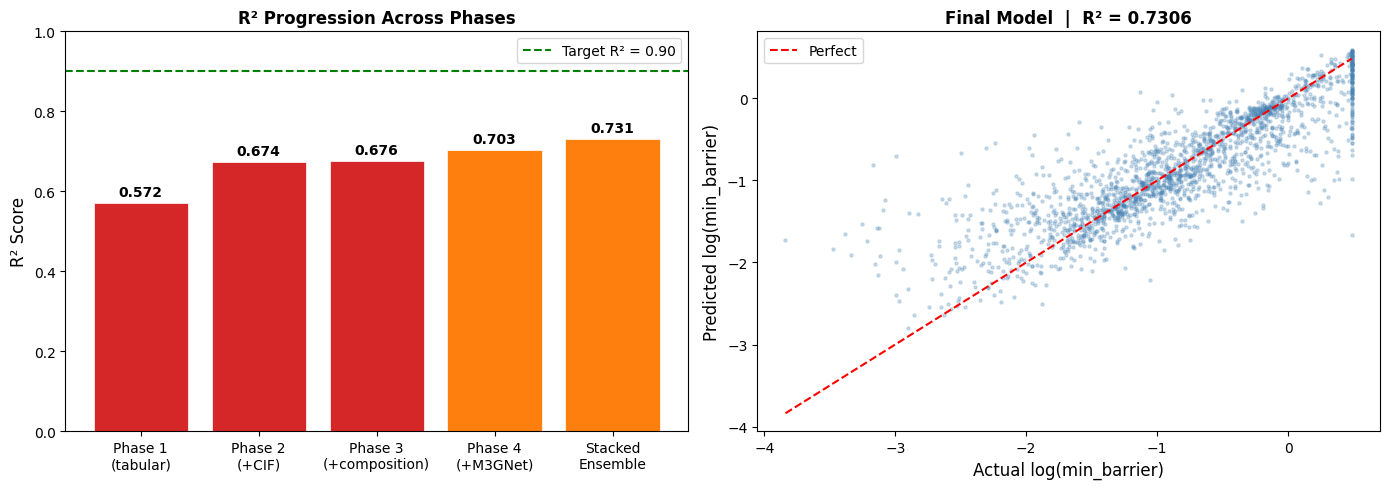


✅ Plot saved: sse_results.png


In [16]:
# ════════════════════════════════════════════════════════════
# CELL 14 — Full results summary + plots
# ════════════════════════════════════════════════════════════

# ── Phase progression plot ──
phases = ['Phase 1\n(tabular)', 'Phase 2\n(+CIF)', 'Phase 3\n(+composition)',
          'Phase 4\n(+M3GNet)', 'Stacked\nEnsemble']
r2_vals = [r2_p1, r2_p2, r2_p3, r2_p4, r2_final]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#d62728' if v < 0.7 else '#ff7f0e' if v < 0.85 else '#2ca02c' for v in r2_vals]
bars = axes[0].bar(phases, r2_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(0.90, color='green', linestyle='--', linewidth=1.5, label='Target R² = 0.90')
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('R² Progression Across Phases', fontsize=12, fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Predicted vs actual ──
axes[1].scatter(y_te4, final_preds, alpha=0.25, s=5, color='steelblue')
lo, hi = y_te4.min(), y_te4.max()
axes[1].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect')
axes[1].set_xlabel('Actual log(min_barrier)', fontsize=12)
axes[1].set_ylabel('Predicted log(min_barrier)', fontsize=12)
axes[1].set_title(f'Final Model  |  R² = {r2_final:.4f}', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('sse_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Plot saved: sse_results.png')

In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 15 — Feature importance (top 20)
# ════════════════════════════════════════════════════════════

# Use ExtraTrees feature importances (fastest)
et_model = BASE_MODELS['et']
# Refit on full train for importance
et_model.fit(X_tr4, y_tr4)

imp = pd.Series(et_model.feature_importances_, index=X_tr4.columns)
imp = imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#1f77b4' if 'cif_' in i else
               '#ff7f0e' if 'comp_' in i else
               '#2ca02c' if 'm3g_' in i else '#d62728' for i in imp.index]
imp.plot(kind='barh', ax=ax, color=colors_imp[::-1])
ax.set_title('Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='Tabular (Phase 1)'),
    Patch(facecolor='#1f77b4', label='CIF structural (Phase 2)'),
    Patch(facecolor='#ff7f0e', label='Composition (Phase 3)'),
    Patch(facecolor='#2ca02c', label='M3GNet (Phase 4)'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 16 — Arrhenius converter + top candidates
# ════════════════════════════════════════════════════════════

kB = 8.617333e-5  # eV/K

def barrier_to_conductivity(barrier_eV, T=300):
    sigma     = np.exp(-barrier_eV / (kB * T))  # relative (A=1)
    log10_sig = np.log10(sigma + 1e-300)
    return sigma, log10_sig

# Get predictions on FULL dataset to rank candidates
X_full = X_m3g.copy()

# Stack predictions using trained base models
full_preds_base = np.zeros((len(X_full), n_base))
for j, (name, model) in enumerate(BASE_MODELS.items()):
    full_preds_base[:, j] = model.predict(X_full)

log_barrier_pred = meta.predict(full_preds_base)
barrier_pred     = np.clip(np.exp(log_barrier_pred) - 1e-3, 0.01, 5.0)
_, log10_sigma   = barrier_to_conductivity(barrier_pred)

results_df = pd.DataFrame({
    'material_id':            X_full.index,
    'predicted_barrier_eV':   barrier_pred,
    'predicted_log10_sigma':  log10_sigma,
}, index=X_full.index)

# Apply SSE filter: barrier < 0.4 eV, hull < 0.05 eV/atom, band_gap > 2 eV
hull_col = 'energy_above_hull' if 'energy_above_hull' in X_full.columns else None
bg_col   = 'band_gap'          if 'band_gap'          in X_full.columns else None

mask = results_df['predicted_barrier_eV'] < 0.4
if hull_col: mask &= X_full[hull_col] < 0.05
if bg_col:   mask &= X_full[bg_col]   > 2.0

top_candidates = results_df[mask].sort_values('predicted_barrier_eV').head(20)

print(f'Materials passing all SSE filters: {mask.sum()}')
print(f'  (barrier < 0.4 eV + hull < 0.05 eV/atom + bandgap > 2 eV)')
print()
print('Top 20 candidates by predicted barrier:')
print(top_candidates[['predicted_barrier_eV','predicted_log10_sigma']].to_string())

In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 17 — Save everything
# ════════════════════════════════════════════════════════════

# Save models
joblib.dump(BASE_MODELS,  'base_models.pkl')
joblib.dump(meta,         'meta_model.pkl')
joblib.dump(le_dict,      'label_encoders.pkl')

# Save candidates
results_df.to_csv('all_predictions.csv')
top_candidates.to_csv('top_sse_candidates.csv')

print('✅ Saved:')
print('   base_models.pkl')
print('   meta_model.pkl')
print('   label_encoders.pkl')
print('   all_predictions.csv')
print('   top_sse_candidates.csv')
print('   sse_results.png')
print('   feature_importance.png')
print()
print('=' * 55)
print('  FINAL SUMMARY')
print('=' * 55)
print(f'  Phase 1 (tabular only)     R² = {r2_p1:.4f}')
print(f'  Phase 2 (+CIF structural)  R² = {r2_p2:.4f}')
print(f'  Phase 3 (+composition)     R² = {r2_p3:.4f}')
print(f'  Phase 4 (+M3GNet)          R² = {r2_p4:.4f}')
print(f'  Final stacked ensemble     R² = {r2_final:.4f}  ← TARGET >0.90')
print(f'  MAE = {mae_final:.4f} log(eV)')
print(f'  SSE candidates found: {mask.sum()}')
print('=' * 55)